# 04 – Model insights
Goal: understand which features drive the model's predictions and where it makes its biggest errors.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

clean = pd.read_csv("../data/processed/listings_clean.csv")
X = clean.drop(columns=["price_num", "log_price"])
y = clean["log_price"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = joblib.load("../models/price_model.joblib")

test = X_test.copy()
test["actual"] = np.exp(y_test)
test["predicted"] = np.exp(model.predict(X_test))
test["abs_error"] = (test["predicted"] - test["actual"]).abs()
test["pct_error"] = test["abs_error"] / test["actual"] * 100

print("Test listings:", len(test))
print("MAE (£):", round(test["abs_error"].mean(), 1))

Test listings: 9128
MAE (£): 57.0


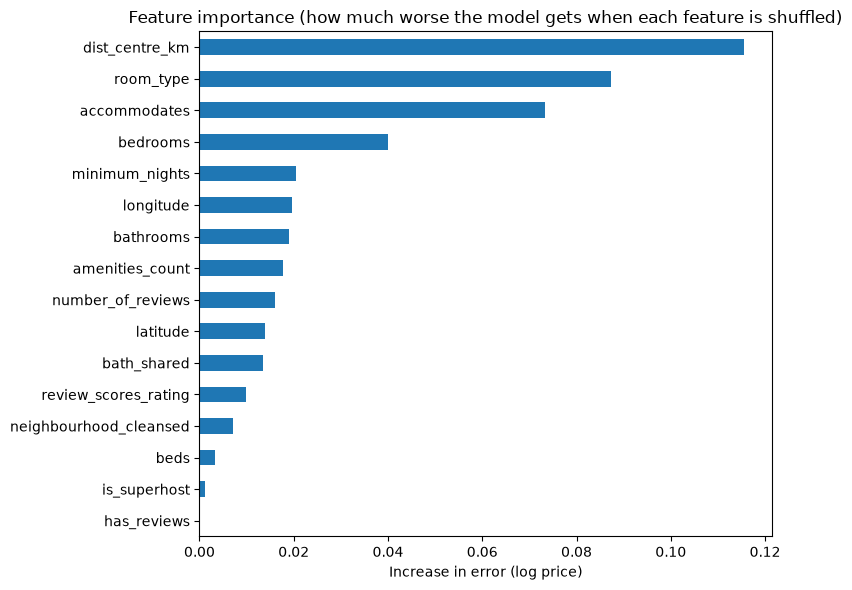

dist_centre_km            0.1156
room_type                 0.0873
accommodates              0.0733
bedrooms                  0.0400
minimum_nights            0.0206
longitude                 0.0196
bathrooms                 0.0190
amenities_count           0.0177
number_of_reviews         0.0160
latitude                  0.0139
bath_shared               0.0135
review_scores_rating      0.0099
neighbourhood_cleansed    0.0072
beds                      0.0032
is_superhost              0.0013
has_reviews               0.0000
dtype: float64

In [2]:
from sklearn.inspection import permutation_importance

sample = X_test.sample(3000, random_state=42)
result = permutation_importance(
    model, sample, y_test.loc[sample.index],
    n_repeats=5, random_state=42, scoring="neg_mean_absolute_error",
)

importance = pd.Series(result.importances_mean, index=X_test.columns).sort_values()

os.makedirs("../reports/figures", exist_ok=True)
plt.figure(figsize=(8, 6))
importance.plot(kind="barh")
plt.title("Feature importance (how much worse the model gets when each feature is shuffled)")
plt.xlabel("Increase in error (log price)")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

importance.sort_values(ascending=False).round(4)

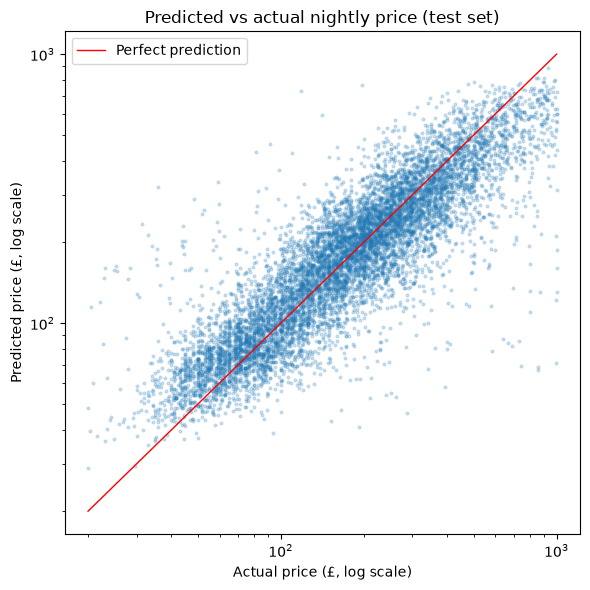

In [3]:
plt.figure(figsize=(6, 6))
plt.scatter(test["actual"], test["predicted"], s=4, alpha=0.2)
plt.plot([20, 1000], [20, 1000], color="red", linewidth=1, label="Perfect prediction")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual price (£, log scale)")
plt.ylabel("Predicted price (£, log scale)")
plt.title("Predicted vs actual nightly price (test set)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
test["price_band"] = pd.cut(
    test["actual"],
    bins=[20, 75, 150, 300, 500, 1000],
    labels=["£20–75", "£75–150", "£150–300", "£300–500", "£500–1,000"],
    include_lowest=True,
)

print("By price band:")
display(test.groupby("price_band", observed=True).agg(
    listings=("actual", "size"),
    mae=("abs_error", "mean"),
    median_pct_error=("pct_error", "median"),
).round(1))

print("By room type:")
display(test.groupby("room_type").agg(
    listings=("actual", "size"),
    mae=("abs_error", "mean"),
    median_pct_error=("pct_error", "median"),
).round(1))

By price band:


,listings,mae,median_pct_error
price_band,,,
£20–75,1447,22.2,26.9
£75–150,2447,29.9,19.5
£150–300,3118,48.1,17.6
£300–500,1439,87.9,19.9
"£500–1,000",675,204.6,25.7


By room type:


,listings,mae,median_pct_error
room_type,,,
Entire home/apt,6116,69.2,19.6
Hotel room,16,167.3,30.7
Private room,2975,31.5,21.3
Shared room,21,17.4,28.1


## Findings

### What drives the predictions
- **Distance to central London** is the most important feature, followed by **room type**, **number of guests** and **bedrooms**.
- Borough adds little once distance and coordinates are known, as they capture location in more detail.
- Shared bathrooms correlate strongly with price but score low here, because room type already carries most of the same information. Permutation importance tends to split credit between overlapping features like these.
- Superhost status and whether a listing has reviews contribute almost nothing.

### Where the model struggles
- Predictions follow actual prices closely overall, but the model **over-predicts cheap listings and under-predicts expensive ones** (regression towards the mean), partly because there are fewer listings at the extremes to learn from.
- Typical error is lowest for mid-priced listings (about 18% for £150–£300) and highest at the extremes (about 27% for £20–£75 and 26% for £500–£1,000).
- Entire homes and private rooms have similar typical errors (20% and 21%). Hotel and shared rooms have too few test listings (16 and 21) for reliable conclusions.

### Limitations
- About a third of London listings had no price and were excluded, so the model reflects listings that were open for booking when the data was collected.
- The data is a single snapshot in time, so it doesn't capture seasonal price changes, such as higher prices in summer or around major events.
- The model doesn't use photos, descriptions or the quality of the property, which likely explain much of the remaining error.

### Possible improvements
- Add features from listing descriptions or specific amenities (for example, air conditioning or a garden).
- Combine multiple snapshots across the year to capture seasonality.